In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from pyswarm import pso

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/diabetes_prediction_dataset (1).csv')

print(df.head())
print(df.info())
print(df.describe())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age               


Missing Values:

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


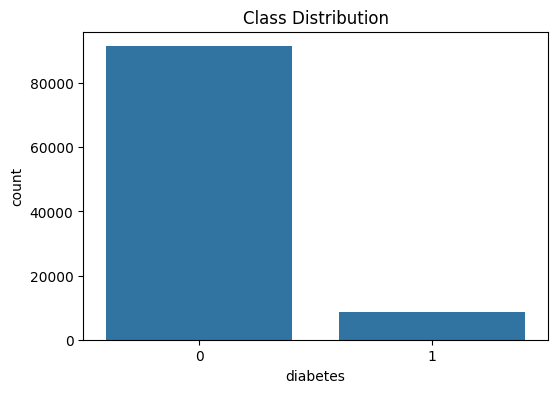

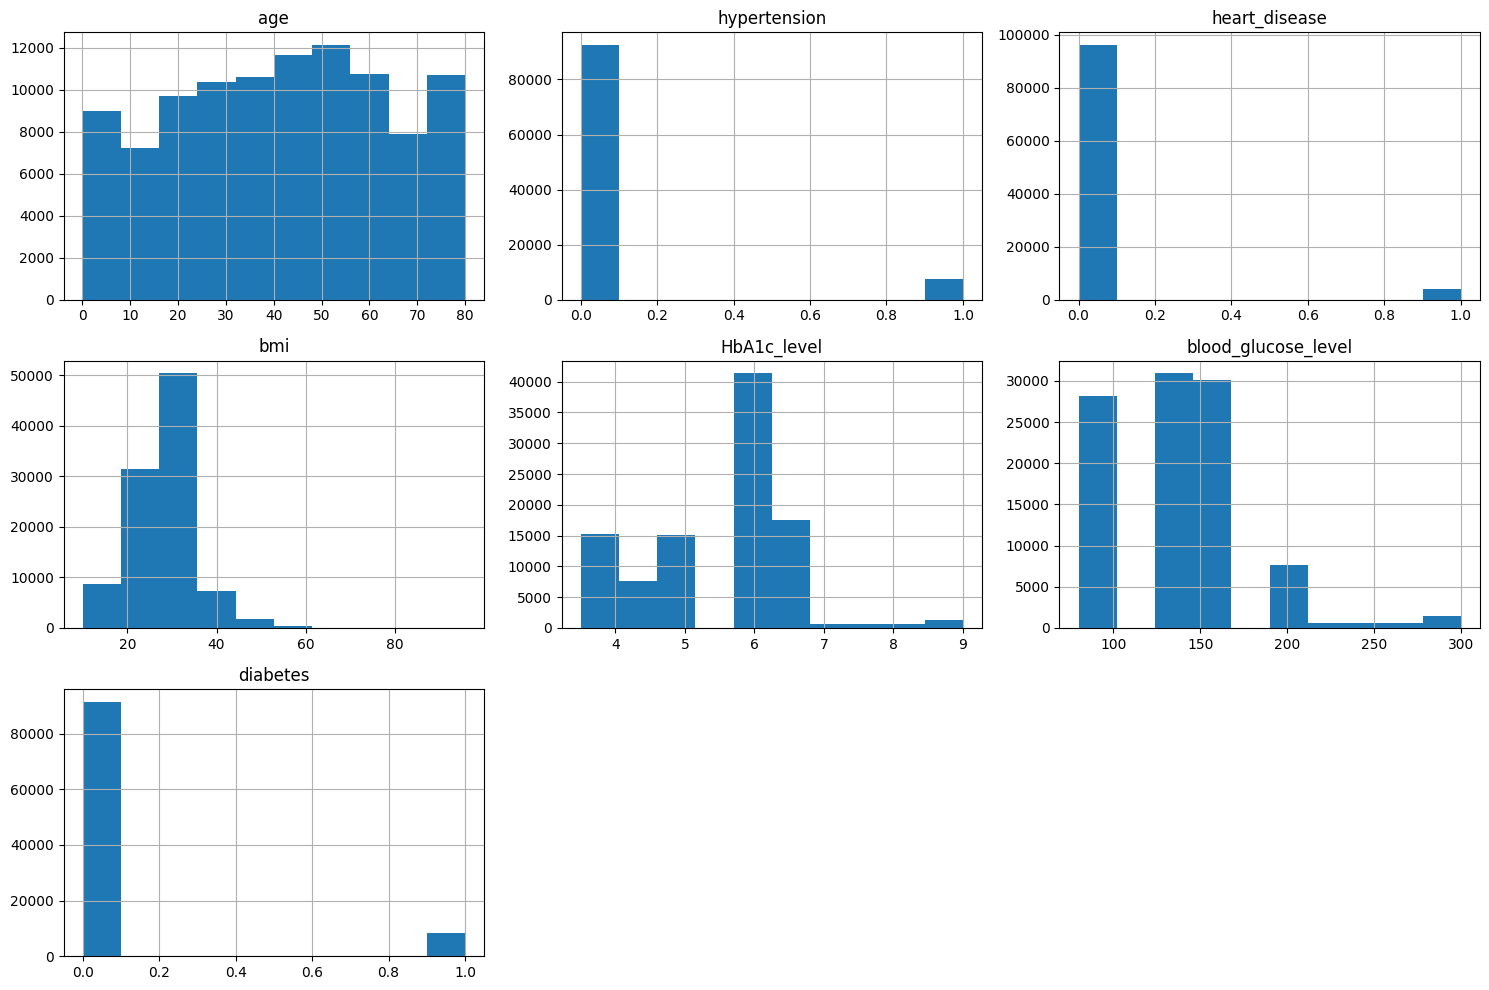

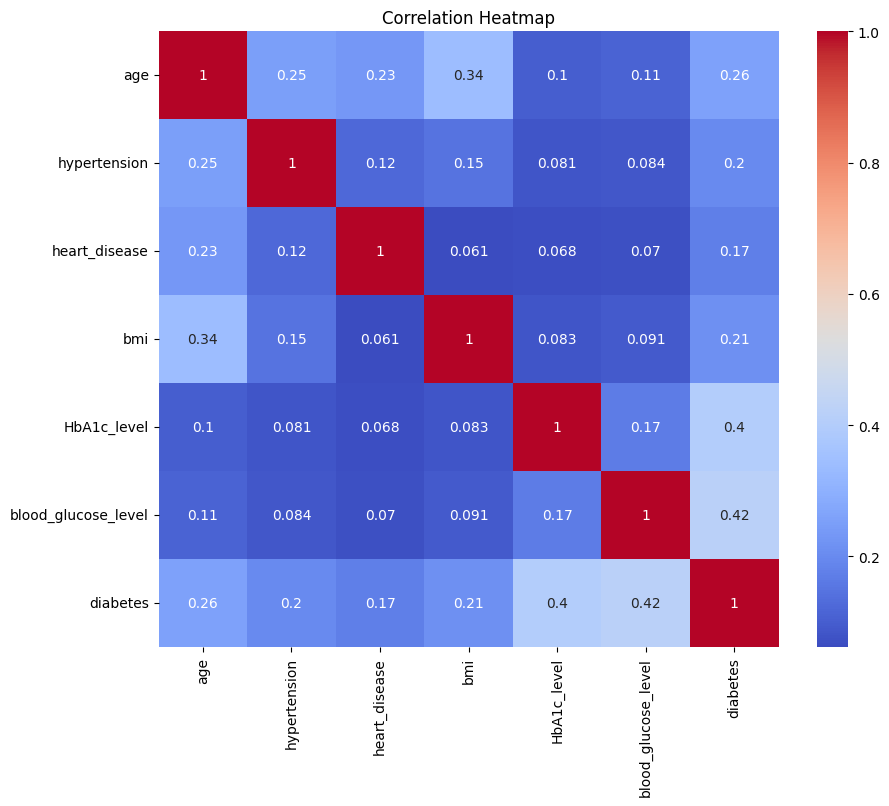

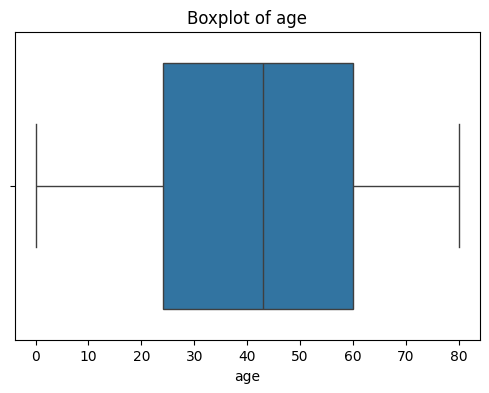

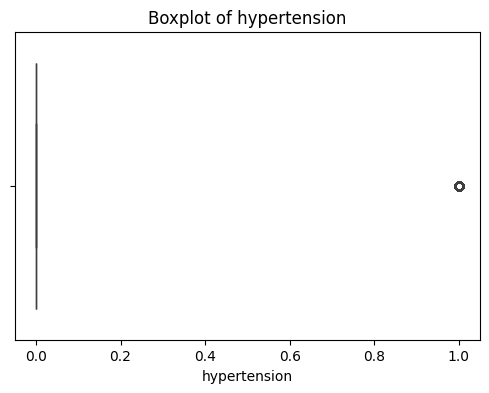

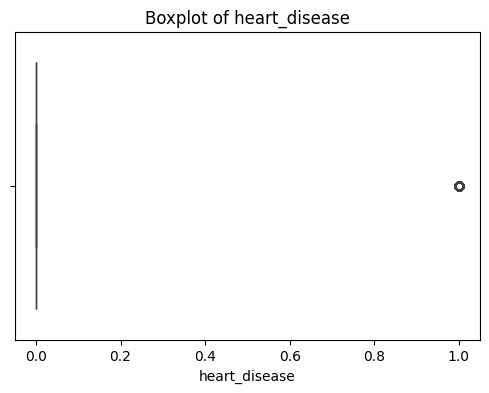

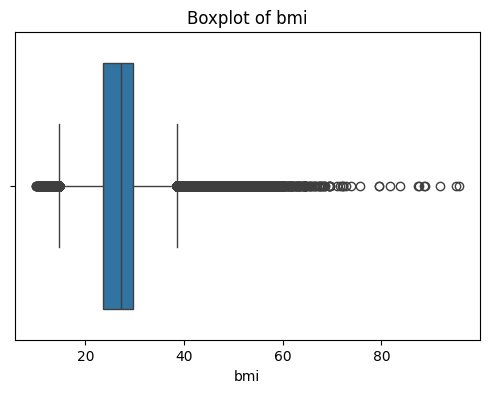

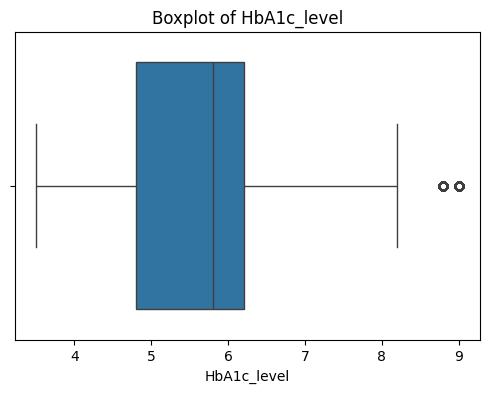

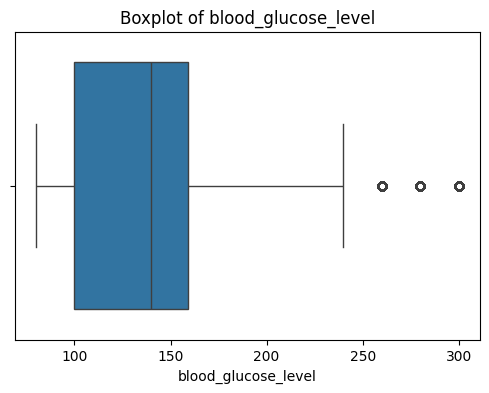

In [3]:
print("\nMissing Values:\n")
print(df.isnull().sum())

# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df['diabetes'])
plt.title('Class Distribution')
plt.show()

# Histograms (numeric columns only)
df.select_dtypes(include=[np.number]).hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

# Correlation Heatmap (numeric columns only)
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Boxplots (numeric columns only, excluding target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'diabetes']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [4]:
# Encode 'gender' with LabelEncoder (Female=0, Male=1, Other=2)
le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

# Encode 'smoking_history' with LabelEncoder
le_smoking = LabelEncoder()
df['smoking_history'] = le_smoking.fit_transform(df['smoking_history'])

print("\nEncoding classes - gender:", list(le_gender.classes_))
print("Encoding classes - smoking_history:", list(le_smoking.classes_))

# Features and Labels
# FIX: Target column is 'diabetes', not 'Outcome'
X = df.drop('diabetes', axis=1)
y = df['diabetes']


Encoding classes - gender: ['Female', 'Male', 'Other']
Encoding classes - smoking_history: ['No Info', 'current', 'ever', 'former', 'never', 'not current']


In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (64000, 8)
Validation Shape: (16000, 8)
Testing Shape: (20000, 8)


 FEATURE SCALING

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

PCA

Original Features: 8
Reduced Features: 8


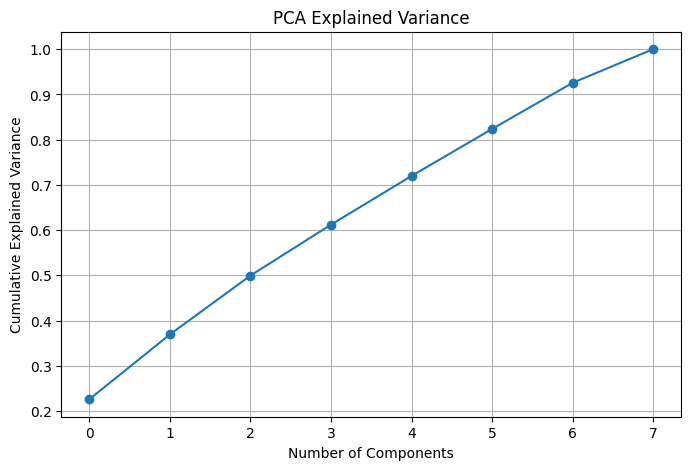

In [7]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X_train_scaled.shape[1])
print("Reduced Features:", X_train_pca.shape[1])

# Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

HELPER FUNCTIONS

In [8]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n========== {model_name} ==========")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return accuracy, precision, recall, f1


def plot_learning_curve(model, X, y, title):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean   = np.mean(val_scores,   axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label='Training Accuracy')
    plt.plot(train_sizes, val_mean,   label='Validation Accuracy')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [9]:
results = []

 LOGISTIC REGRESSION



LOGISTIC REGRESSION

========== Logistic Regression ==========
Accuracy : 0.9602
Precision: 0.8587301587301587
Recall   : 0.6364705882352941
F1 Score : 0.731081081081081

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000



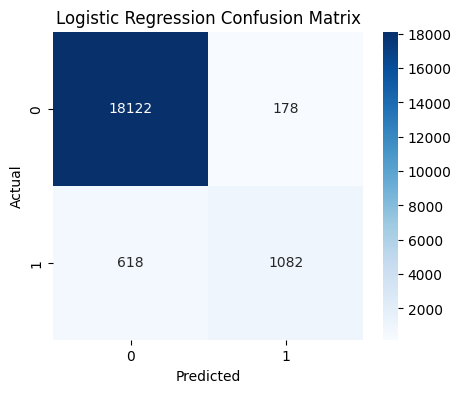

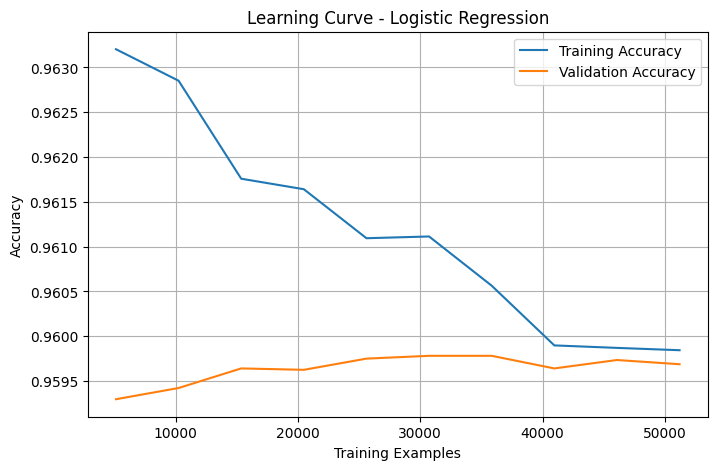


========== Logistic Regression PCA ==========
Accuracy : 0.9602
Precision: 0.8587301587301587
Recall   : 0.6364705882352941
F1 Score : 0.731081081081081

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000



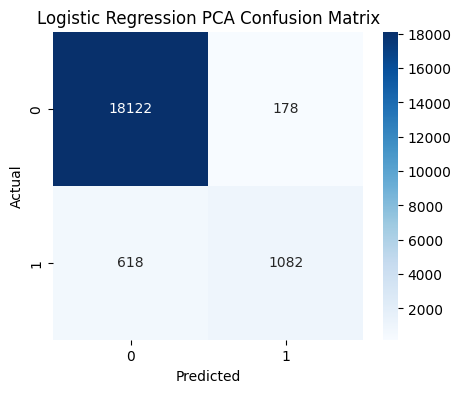

In [10]:
print("\nLOGISTIC REGRESSION")

lr = LogisticRegression(max_iter=1000)

acc, prec, rec, f1 = evaluate_model(
    lr,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    'Logistic Regression'
)

results.append(['Logistic Regression', 'Without PCA', acc, prec, rec, f1])

plot_learning_curve(
    lr,
    X_train_scaled,
    y_train,
    'Learning Curve - Logistic Regression'
)

# PCA Version

lr_pca = LogisticRegression(max_iter=1000)

acc, prec, rec, f1 = evaluate_model(
    lr_pca,
    X_train_pca,
    y_train,
    X_test_pca,
    y_test,
    'Logistic Regression PCA'
)

results.append(['Logistic Regression', 'With PCA', acc, prec, rec, f1])

LEARNING CURVE FUNCTION

In [11]:
def plot_learning_curve(model, X, y, title):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_sizes,
        train_mean,
        marker='o',
        label='Training Accuracy'
    )

    plt.plot(
        train_sizes,
        val_mean,
        marker='o',
        label='Validation Accuracy'
    )

    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.title(title)

    plt.legend()
    plt.grid()

    plt.show()

OPTIMIZED MLP MODEL

In [12]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

TRAIN & EVALUATE

Iteration 1, loss = 0.17686848
Validation score: 0.960156
Iteration 2, loss = 0.11443425
Validation score: 0.962500
Iteration 3, loss = 0.11050698
Validation score: 0.964375
Iteration 4, loss = 0.10534829
Validation score: 0.965781
Iteration 5, loss = 0.10203951
Validation score: 0.967031
Iteration 6, loss = 0.09964423
Validation score: 0.967187
Iteration 7, loss = 0.09798510
Validation score: 0.967031
Iteration 8, loss = 0.09675354
Validation score: 0.969531
Iteration 9, loss = 0.09579269
Validation score: 0.969375
Iteration 10, loss = 0.09469805
Validation score: 0.968437
Iteration 11, loss = 0.09380491
Validation score: 0.968750
Iteration 12, loss = 0.09185897
Validation score: 0.969375
Iteration 13, loss = 0.08979297
Validation score: 0.969375
Iteration 14, loss = 0.08778746
Validation score: 0.970469
Iteration 15, loss = 0.08622103
Validation score: 0.971562
Iteration 16, loss = 0.08533512
Validation score: 0.972656
Iteration 17, loss = 0.08441464
Validation score: 0.971094
Iterat

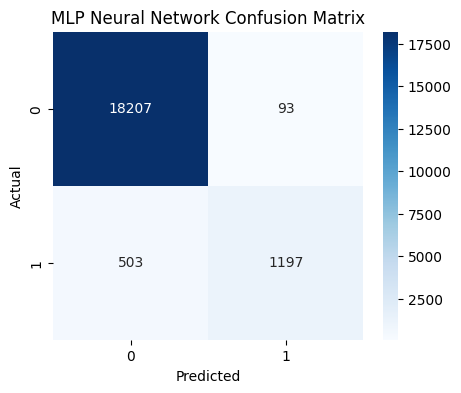

In [13]:

acc, prec, rec, f1 = evaluate_model(
    mlp,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    'MLP Neural Network'
)

results.append([
    'MLP',
    'Without PCA',
    acc,
    prec,
    rec,
    f1
])


 LEARNING CURVE

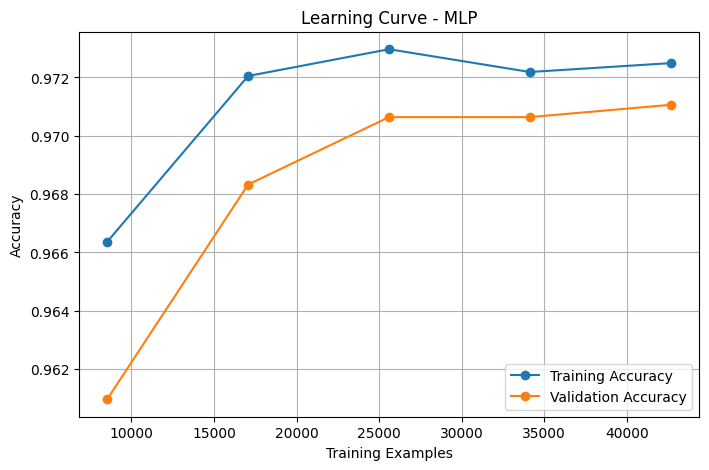

In [14]:
plot_learning_curve(
    mlp,
    X_train_scaled,
    y_train,
    'Learning Curve - MLP'
)

PCA VERSION


MLP NEURAL NETWORK WITH PCA
Iteration 1, loss = 0.17138967
Validation score: 0.962187
Iteration 2, loss = 0.11387480
Validation score: 0.961406
Iteration 3, loss = 0.11081394
Validation score: 0.963281
Iteration 4, loss = 0.10760813
Validation score: 0.964531
Iteration 5, loss = 0.10300949
Validation score: 0.965156
Iteration 6, loss = 0.09862223
Validation score: 0.967500
Iteration 7, loss = 0.09548943
Validation score: 0.967344
Iteration 8, loss = 0.09318260
Validation score: 0.970156
Iteration 9, loss = 0.09124359
Validation score: 0.970156
Iteration 10, loss = 0.08967116
Validation score: 0.969688
Iteration 11, loss = 0.08885611
Validation score: 0.970000
Iteration 12, loss = 0.08754846
Validation score: 0.970000
Iteration 13, loss = 0.08686141
Validation score: 0.970156
Iteration 14, loss = 0.08596585
Validation score: 0.970313
Iteration 15, loss = 0.08541769
Validation score: 0.971562
Iteration 16, loss = 0.08493070
Validation score: 0.971719
Iteration 17, loss = 0.08433530
Vali

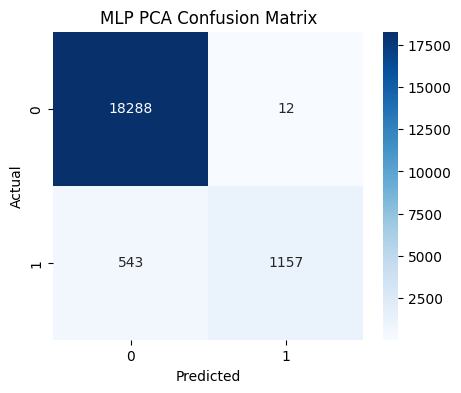

In [15]:
print("\nMLP NEURAL NETWORK WITH PCA")


mlp_pca = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)


acc, prec, rec, f1 = evaluate_model(
    mlp_pca,
    X_train_pca,
    y_train,
    X_test_pca,
    y_test,
    'MLP PCA'
)

results.append([
    'MLP',
    'With PCA',
    acc,
    prec,
    rec,
    f1
])

SVM LINEAR



SVM LINEAR

========== SVM Linear ==========
Accuracy : 0.961
Precision: 0.9049295774647887
Recall   : 0.6047058823529412
F1 Score : 0.7249647390691114

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18300
           1       0.90      0.60      0.72      1700

    accuracy                           0.96     20000
   macro avg       0.93      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



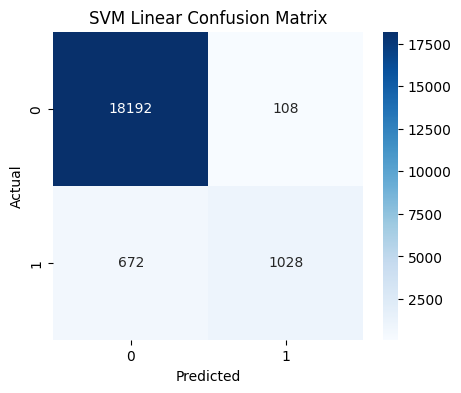

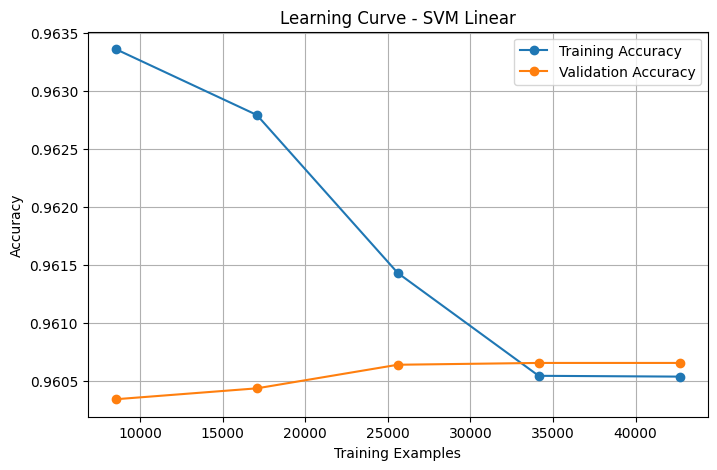

In [16]:
print("\nSVM LINEAR")

svm_linear = SVC(kernel='linear', probability=True)

acc, prec, rec, f1 = evaluate_model(
    svm_linear,
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    'SVM Linear'
)

results.append(['SVM Linear', 'Without PCA', acc, prec, rec, f1])

plot_learning_curve(
    svm_linear,
    X_train_scaled, y_train,
    'Learning Curve - SVM Linear'
)

# PCA VERSION

print("\nSVM LINEAR WITH PCA")

svm_linear_pca = SVC(kernel='linear', probability=True)

acc, prec, rec, f1 = evaluate_model(
    svm_linear_pca,
    X_train_pca, y_train,
    X_test_pca,  y_test,
    'SVM Linear PCA'
)

results.append(['SVM Linear', 'With PCA', acc, prec, rec, f1])

plot_learning_curve(
    svm_linear_pca,
    X_train_pca, y_train,
    'Learning Curve - SVM Linear PCA'
)



SVM RBF WITH GRID SEARCH


SVM RBF WITH GRID SEARCH
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

========== SVM RBF GridSearch ==========
Accuracy : 0.9679
Precision: 0.9616055846422339
Recall   : 0.648235294117647
F1 Score : 0.7744202389318342

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.96      0.65      0.77      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.82      0.88     20000
weighted avg       0.97      0.97      0.97     20000



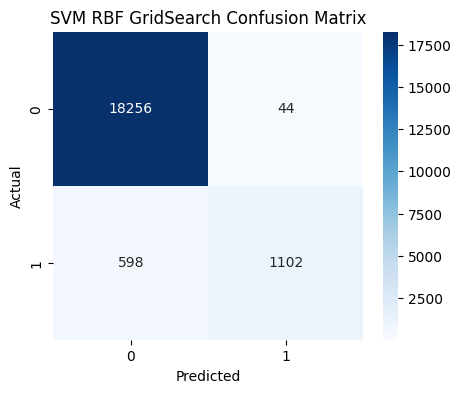

In [17]:
print("\nSVM RBF WITH GRID SEARCH")

# Sample 5000 rows for hyperparameter search only (full data is too slow)
sample_idx = np.random.RandomState(42).choice(len(X_train_scaled), size=5000, replace=False)
X_train_svm_sample     = X_train_scaled[sample_idx]
X_train_pca_sample     = X_train_pca[sample_idx]
y_train_svm_sample     = y_train.iloc[sample_idx]

param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    verbose=1,
    scoring='accuracy'
)

svm_grid.fit(X_train_svm_sample, y_train_svm_sample)

print("Best Parameters:", svm_grid.best_params_)

best_svm = svm_grid.best_estimator_

acc, prec, rec, f1 = evaluate_model(
    best_svm,
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    'SVM RBF GridSearch'
)

results.append(['SVM RBF GridSearch', 'Without PCA', acc, prec, rec, f1])

plot_learning_curve(
    best_svm,
    X_train_scaled, y_train,
    'Learning Curve - SVM RBF GridSearch'
)

# PCA VERSION

print("\nSVM RBF GRID SEARCH WITH PCA")

svm_grid_pca = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    verbose=1,
    scoring='accuracy'
)

svm_grid_pca.fit(X_train_pca_sample, y_train_svm_sample)

print("Best Parameters (PCA):", svm_grid_pca.best_params_)

best_svm_pca = svm_grid_pca.best_estimator_

acc, prec, rec, f1 = evaluate_model(
    best_svm_pca,
    X_train_pca, y_train,
    X_test_pca,  y_test,
    'SVM RBF GridSearch PCA'
)

results.append(['SVM RBF GridSearch', 'With PCA', acc, prec, rec, f1])

plot_learning_curve(
    best_svm_pca,
    X_train_pca, y_train,
    'Learning Curve - SVM RBF GridSearch PCA'
)

PARTICLE SWARM OPTIMIZATION (PSO)


PSO OPTIMIZATION
Stopping search: maximum iterations reached --> 20
Best C    : 41.57390675734213
Best Gamma: 0.11843579026242868

========== SVM PSO ==========
Accuracy : 0.9677
Precision: 0.9630931458699473
Recall   : 0.6447058823529411
F1 Score : 0.7723749119097957

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.96      0.64      0.77      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.82      0.88     20000
weighted avg       0.97      0.97      0.96     20000



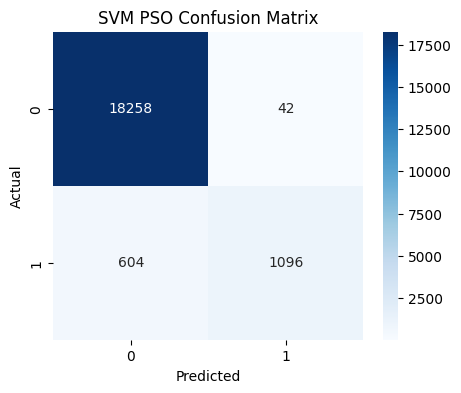

In [18]:
print("\nPSO OPTIMIZATION")

# Reuse same 5000-row sample from GridSearch above

lb = [0.1,  0.0001]
ub = [100,  1.0   ]


def svm_pso(params):

    C     = params[0]
    gamma = params[1]

    model = SVC(kernel='rbf', C=C, gamma=gamma)

    scores = cross_val_score(
        model,
        X_train_svm_sample,
        y_train_svm_sample,
        cv=5,
        scoring='accuracy'
    )

    return -scores.mean()


best_params, _ = pso(
    svm_pso,
    lb,
    ub,
    swarmsize=20,
    maxiter=20
)

best_C     = best_params[0]
best_gamma = best_params[1]

print("Best C    :", best_C)
print("Best Gamma:", best_gamma)

svm_pso_model = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma,
    probability=True
)

acc, prec, rec, f1 = evaluate_model(
    svm_pso_model,
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    'SVM PSO'
)

results.append(['SVM PSO', 'Without PCA', acc, prec, rec, f1])

plot_learning_curve(
    svm_pso_model,
    X_train_scaled, y_train,
    'Learning Curve - SVM PSO'
)

# PCA VERSION

print("\nPSO OPTIMIZATION WITH PCA")


def svm_pso_pca(params):

    C     = params[0]
    gamma = params[1]

    model = SVC(kernel='rbf', C=C, gamma=gamma)

    scores = cross_val_score(
        model,
        X_train_pca_sample,
        y_train_svm_sample,
        cv=5,
        scoring='accuracy'
    )

    return -scores.mean()


best_params_pca, _ = pso(
    svm_pso_pca,
    lb,
    ub,
    swarmsize=20,
    maxiter=20
)

best_C_pca     = best_params_pca[0]
best_gamma_pca = best_params_pca[1]

print("Best C (PCA)    :", best_C_pca)
print("Best Gamma (PCA):", best_gamma_pca)

svm_pso_pca_model = SVC(
    kernel='rbf',
    C=best_C_pca,
    gamma=best_gamma_pca,
    probability=True
)

acc, prec, rec, f1 = evaluate_model(
    svm_pso_pca_model,
    X_train_pca, y_train,
    X_test_pca,  y_test,
    'SVM PSO PCA'
)

results.append(['SVM PSO', 'With PCA', acc, prec, rec, f1])

plot_learning_curve(
    svm_pso_pca_model,
    X_train_pca, y_train,
    'Learning Curve - SVM PSO PCA'
)


NAIVE BAYES


NAIVE BAYES

========== Naive Bayes ==========
Accuracy : 0.90445
Precision: 0.4569563443492452
Recall   : 0.6588235294117647
F1 Score : 0.5396290050590219

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     18300
           1       0.46      0.66      0.54      1700

    accuracy                           0.90     20000
   macro avg       0.71      0.79      0.74     20000
weighted avg       0.92      0.90      0.91     20000



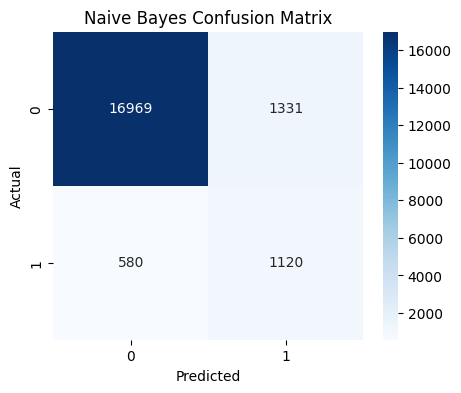

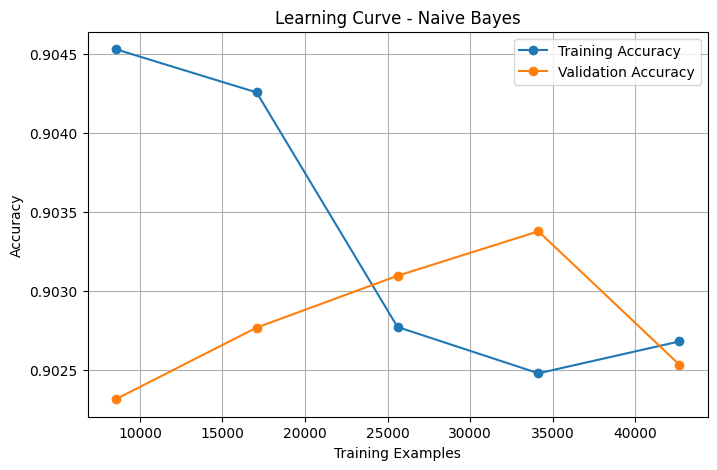

In [19]:
print("\nNAIVE BAYES")

nb = GaussianNB()

acc, prec, rec, f1 = evaluate_model(
    nb,
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    'Naive Bayes'
)

results.append(['Naive Bayes', 'Without PCA', acc, prec, rec, f1])

plot_learning_curve(
    nb,
    X_train_scaled, y_train,
    'Learning Curve - Naive Bayes'
)

# PCA VERSION

print("\nNAIVE BAYES WITH PCA")

nb_pca = GaussianNB()

acc, prec, rec, f1 = evaluate_model(
    nb_pca,
    X_train_pca, y_train,
    X_test_pca,  y_test,
    'Naive Bayes PCA'
)

results.append(['Naive Bayes', 'With PCA', acc, prec, rec, f1])

plot_learning_curve(
    nb_pca,
    X_train_pca, y_train,
    'Learning Curve - Naive Bayes PCA'
)

RANDOM FOREST


RANDOM FOREST

========== Random Forest ==========
Accuracy : 0.97225
Precision: 0.9982593559617058
Recall   : 0.6747058823529412
F1 Score : 0.8051948051948052

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       1.00      0.67      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



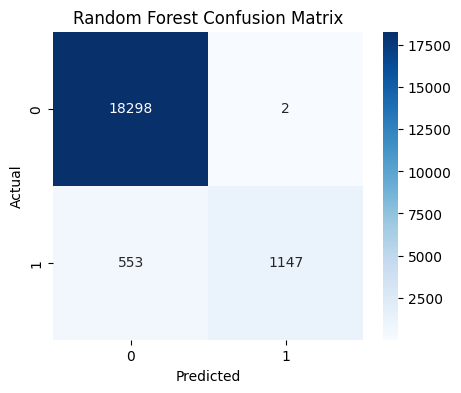

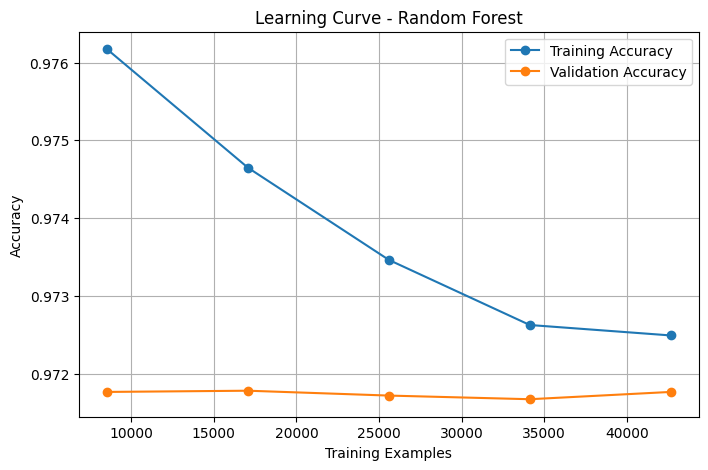

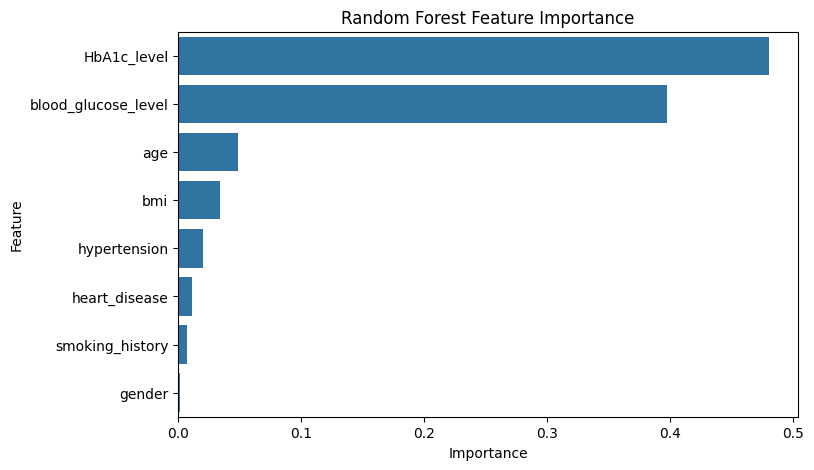


RANDOM FOREST WITH PCA

========== Random Forest PCA ==========
Accuracy : 0.96285
Precision: 0.9459459459459459
Recall   : 0.5970588235294118
F1 Score : 0.7320591417237649

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.95      0.60      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.95      0.80      0.86     20000
weighted avg       0.96      0.96      0.96     20000



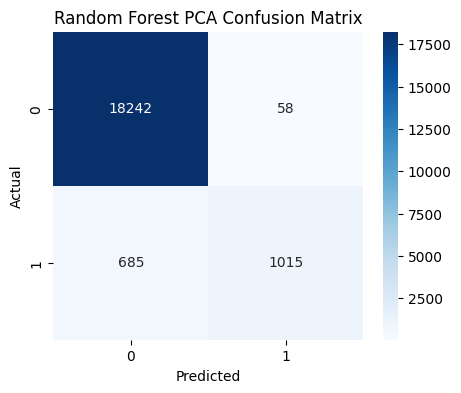

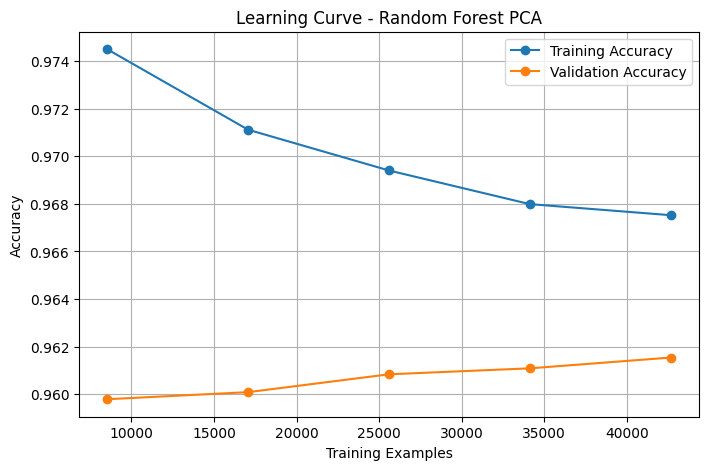

In [35]:
print("\nRANDOM FOREST")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

acc, prec, rec, f1 = evaluate_model(
    rf,
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    'Random Forest'
)

results.append(['Random Forest', 'Without PCA', acc, prec, rec, f1])

plot_learning_curve(
    rf,
    X_train_scaled, y_train,
    'Learning Curve - Random Forest'
)

# Feature Importance
importance = rf.feature_importances_

feat_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title('Random Forest Feature Importance')
plt.show()

# PCA VERSION

print("\nRANDOM FOREST WITH PCA")

rf_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

acc, prec, rec, f1 = evaluate_model(
    rf_pca,
    X_train_pca, y_train,
    X_test_pca,  y_test,
    'Random Forest PCA'
)

results.append(['Random Forest', 'With PCA', acc, prec, rec, f1])

plot_learning_curve(
    rf_pca,
    X_train_pca, y_train,
    'Learning Curve - Random Forest PCA'
)

XGBOOST (Best Model)


XGBOOST

========== XGBoost ==========
Accuracy : 0.9725
Precision: 0.9799666110183639
Recall   : 0.6905882352941176
F1 Score : 0.8102139406487232

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       0.98      0.69      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



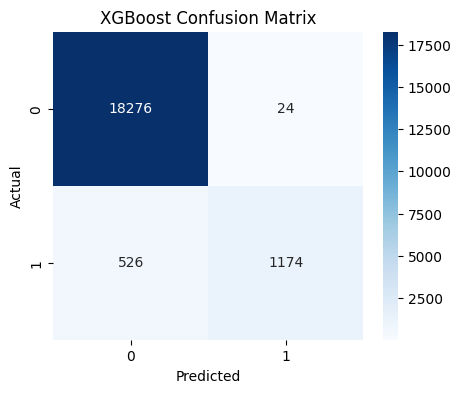

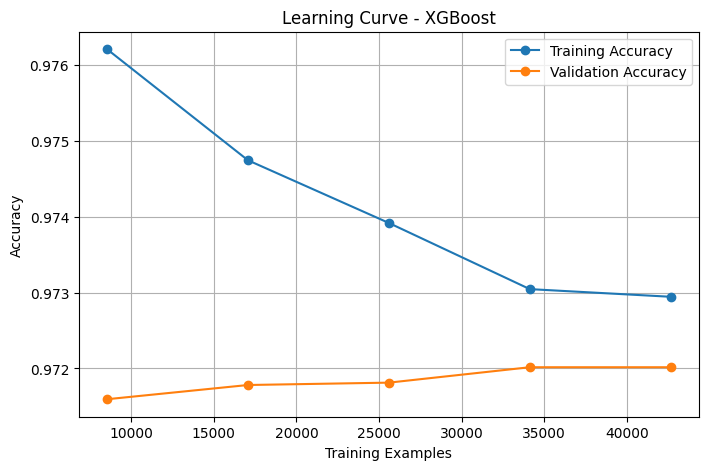

In [28]:
print("\nXGBOOST")

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

acc, prec, rec, f1 = evaluate_model(
    xgb,
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    'XGBoost'
)

results.append(['XGBoost', 'Without PCA', acc, prec, rec, f1])

plot_learning_curve(
    xgb,
    X_train_scaled, y_train,
    'Learning Curve - XGBoost'
)


XGBOOST WITH PCA

========== XGBoost PCA ==========
Accuracy : 0.96725
Precision: 0.9416737109044802
Recall   : 0.6552941176470588
F1 Score : 0.7728061047519944

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.94      0.66      0.77      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.83      0.88     20000
weighted avg       0.97      0.97      0.96     20000



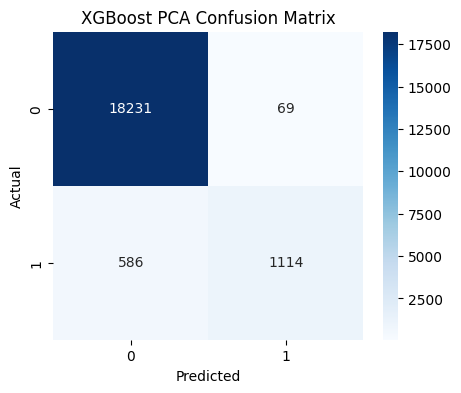

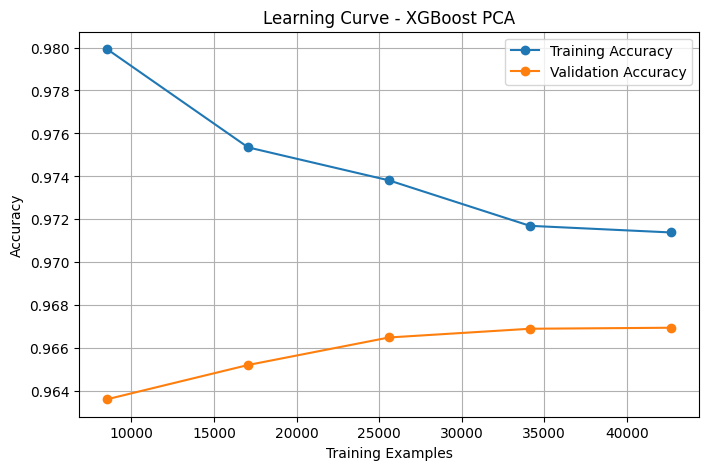

In [29]:
# PCA VERSION

print("\nXGBOOST WITH PCA")

xgb_pca = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

acc, prec, rec, f1 = evaluate_model(
    xgb_pca,
    X_train_pca, y_train,
    X_test_pca,  y_test,
    'XGBoost PCA'
)

results.append(['XGBoost', 'With PCA', acc, prec, rec, f1])

plot_learning_curve(
    xgb_pca,
    X_train_pca, y_train,
    'Learning Curve - XGBoost PCA'
)


FINAL COMPARISON TABLE

In [30]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'PCA', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)

print(results_df)


                  Model          PCA  Accuracy  Precision    Recall  F1 Score
0   Logistic Regression  Without PCA   0.96020   0.858730  0.636471  0.731081
1   Logistic Regression     With PCA   0.96020   0.858730  0.636471  0.731081
2                   MLP  Without PCA   0.97020   0.927907  0.704118  0.800669
3                   MLP     With PCA   0.97225   0.989735  0.680588  0.806553
4            SVM Linear  Without PCA   0.96100   0.904930  0.604706  0.724965
5    SVM RBF GridSearch  Without PCA   0.96790   0.961606  0.648235  0.774420
6               SVM PSO  Without PCA   0.96770   0.963093  0.644706  0.772375
7           Naive Bayes  Without PCA   0.90445   0.456956  0.658824  0.539629
8         Random Forest  Without PCA   0.97225   0.998259  0.674706  0.805195
9               XGBoost  Without PCA   0.97250   0.979967  0.690588  0.810214
10              XGBoost  Without PCA   0.97250   0.979967  0.690588  0.810214
11              XGBoost     With PCA   0.96725   0.941674  0.655

VISUAL COMPARISON

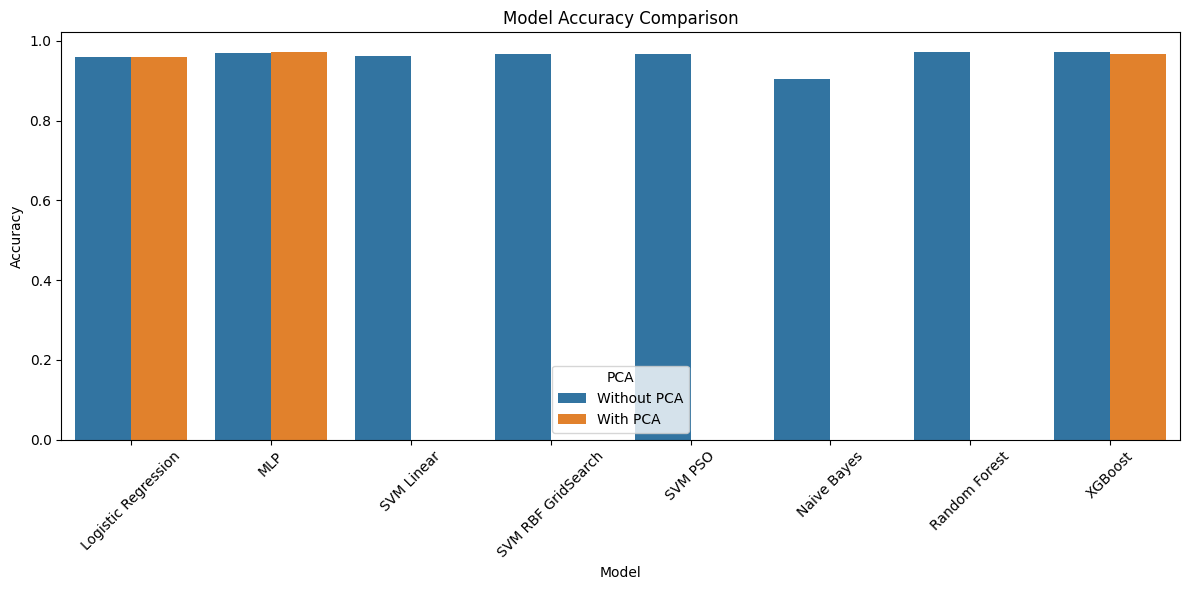

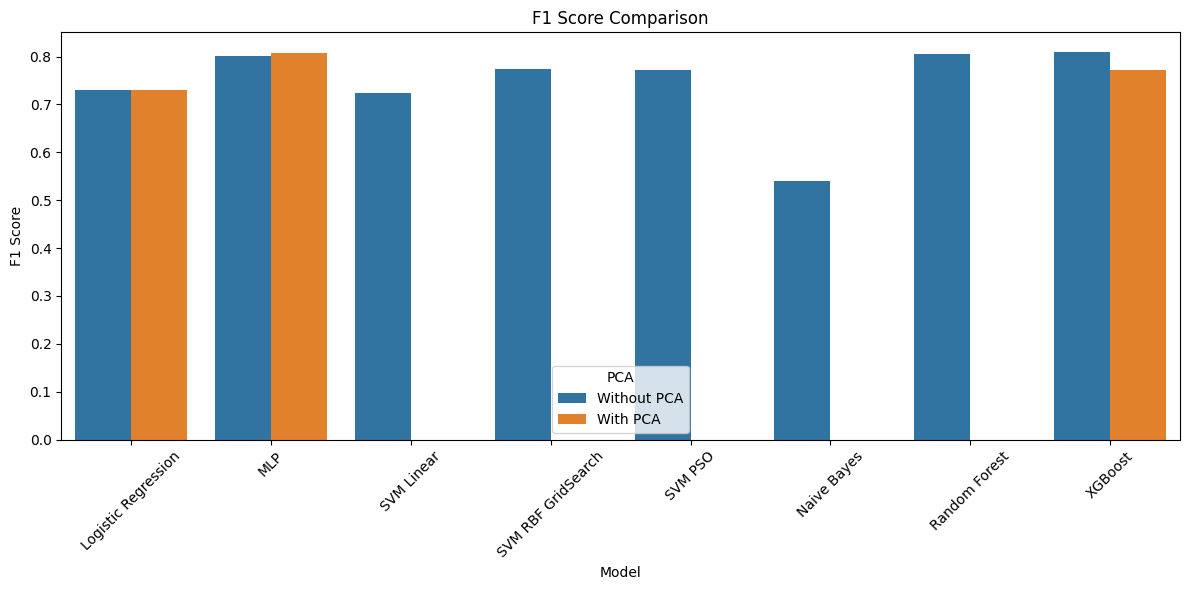

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', hue='PCA', data=results_df)
plt.xticks(rotation=45)
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1 Score', hue='PCA', data=results_df)
plt.xticks(rotation=45)
plt.title('F1 Score Comparison')
plt.tight_layout()
plt.show()

BEST MODEL

In [32]:
best_model_row = results_df.sort_values(by='Accuracy', ascending=False)

print("\nBEST MODEL:\n")
print(best_model_row.head(1))


BEST MODEL:

     Model          PCA  Accuracy  Precision    Recall  F1 Score
9  XGBoost  Without PCA    0.9725   0.979967  0.690588  0.810214


ROC CURVE

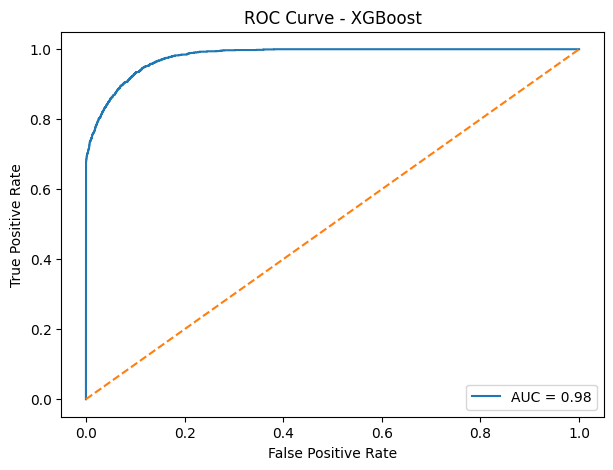

In [33]:
best_classifier = xgb

best_classifier.fit(X_train_scaled, y_train)

probs = best_classifier.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

SAVE RESULTS

In [34]:
results_df.to_csv('final_model_results.csv', index=False)

print("\nProject Completed Successfully!")


Project Completed Successfully!
